## Denoising Diffusion Probabilistic Models

In [14]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from typing import Union

from diffusers import DDPMScheduler, DDIMScheduler
from diffusers.training_utils import EMAModel
from diffusers.optimization import get_scheduler

#imports for environment
from skvideo.io import vwrite
from IPython.display import Video

import pytorch_kinematics as pk

from tqdm.auto import tqdm
import time
from abc import ABC, abstractmethod

torch.manual_seed(0)
np.random.seed(0)

[Diffuser paper](https://arxiv.org/pdf/2205.099917)

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEBUG = False
print(f"Using device: {device}")

Using device: cuda


### **Dataset**

In [16]:
torch.manual_seed(0)
np.random.seed(0)
def sample_random_config():
    joint_limits = [
        (-2.8973, 2.8973),  # joint 1
        (-1.7628, 1.7628),  # joint 2
        (-2.8973, 2.8973),  # joint 3
        (-3.0718, -0.0698), # joint 4
        (-2.8973, 2.8973),  # joint 5
        (-0.0175, 3.7525),  # joint 6
        (-2.8973, 2.8973)   # joint 7
    ]

    config = []
    for (lower, upper) in joint_limits:
        angle = np.random.uniform(lower, upper)
        config.append(angle)

    return np.array(config, dtype=np.float32)

def generate_trajectory_data(num_trajectories, trajectory_length, device):
    trajectories = []
    for _ in tqdm(range(num_trajectories), desc="Generating trajectories"):
        start_config = sample_random_config()
        end_config = sample_random_config()
        alphas = np.linspace(0, 1, num=trajectory_length).reshape(-1, 1)  # [trajectory_length, 1]
        trajectory = start_config * (1 - alphas) + end_config * alphas  # [trajectory_length, 7]
        for j in range(7):
            freq = np.random.uniform(1, 3)
            amp = np.random.uniform(0.0, 0.15)
            phase = np.random.uniform(0, 2 * np.pi)
            perturbation = amp * np.sin(freq * np.pi * alphas.flatten() + phase)
            # Zero out at endpoints so start/goal are exact
            perturbation *= np.sin(np.pi * alphas.flatten())  # envelope
            trajectory[:, j] += perturbation
        trajectories.append(trajectory)
    return np.stack(trajectories)  # [num_trajectories, trajectory_length, 7]

def generate_trajectory_stats(trajectories: np.ndarray):
    # trajectories: [num_trajectories, trajectory_length, 7]
    max_num = trajectories.max(axis=(0,1))  # [7]
    min_num = trajectories.min(axis=(0,1))  # [7]
    stats = {"max": max_num, "min": min_num}
    return stats

def normalize_trajectories(trajectories, stats):
    # trajectories: [num_trajectories, trajectory_length, 7]
    # stats: {"max": [7], "min": [7]}
    normalized = (trajectories - stats["min"]) / (stats["max"] - stats["min"])
    normalized = normalized * 2 -1
    return normalized

def unnormalize_trajectories(normalized, stats):
    unnormalized = (normalized + 1) / 2
    unnormalized = unnormalized * (stats["max"] - stats["min"]) + stats["min"]
    return unnormalized

def normalize_trajectories_torch(trajectories, stats):
    # trajectories: [num_trajectories, trajectory_length, 7]
    # stats: {"max": [7], "min": [7]}
    normalized = (trajectories - torch.from_numpy(stats["min"]).to(trajectories.device)) / (torch.from_numpy(stats["max"] - stats["min"]).to(trajectories.device))
    normalized = normalized * 2 -1
    return normalized

def unnormalize_trajectories_torch(normalized, stats):
    unnormalized = (normalized + 1) / 2
    unnormalized = unnormalized * torch.from_numpy(stats["max"] - stats["min"]).to(normalized.device) + torch.from_numpy(stats["min"]).to(normalized.device)
    return unnormalized

planning_horizon = 32
num_trajectories = 1000

trajectory_data_np = generate_trajectory_data(num_trajectories=num_trajectories, trajectory_length=planning_horizon, device=device)
stats = generate_trajectory_stats(trajectory_data_np)
print("Trajectory data shape:", trajectory_data_np.shape)
print("Trajectory data stats:", stats)

Generating trajectories:   0%|          | 0/1000 [00:00<?, ?it/s]

Trajectory data shape: (1000, 32, 7)
Trajectory data stats: {'max': array([ 2.98118913,  1.78443564,  2.89682913, -0.01819678,  2.89427662,
        3.74930733,  2.89704847]), 'min': array([-2.89596391, -1.84346155, -2.89395642, -3.07954466, -2.9116636 ,
       -0.01574198, -2.89688015])}


In [17]:
class TrajectoryDataset(torch.utils.data.Dataset):
    def __init__(self, trajectories: np.ndarray, stats: dict):
        self.trajectories = normalize_trajectories(trajectories, stats)
        self.stats = stats

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        trajectory = self.trajectories[idx]  # [trajectory_length, 7]
        return torch.tensor(trajectory, dtype=torch.float32)

In [18]:
dataset = TrajectoryDataset(trajectory_data_np, stats)

# create dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    shuffle=True,
    # accelerate cpu-gpu transfer
    pin_memory=True,
    # don't kill worker process afte each epoch
    # persistent_workers=True
)

# visualize data in batch
batch = next(iter(dataloader))
print("Batch shape:", batch.shape)  # [batch_size, trajectory_length, 7]

Batch shape: torch.Size([32, 32, 7])


### **Robot**
Uses Franka Panda arm.

[URDF GitHub Repo](https://github.com/google-deepmind/mujoco_menagerie#)

In [19]:
import os

mjcf_dir = "robot_models/franka_emika_panda"
assets = {}
for filename in os.listdir(os.path.join(mjcf_dir, "assets")):
    with open(os.path.join(mjcf_dir, "assets", filename), "rb") as f:
        assets[filename] = f.read()

chain = pk.build_chain_from_mjcf(
    open(os.path.join(mjcf_dir, "panda.xml")).read(),
    assets=assets
)
print(chain.get_joint_parameter_names())  # see what joints are available
print(chain.get_link_names())  # see what links are available
robot = pk.SerialChain(chain, "link7")
robot = robot.to(device=device)  # GPU if available

# # Batched FK — works on entire trajectories at once
# # q: [32, 7] trajectory of joint configs
q = torch.randn(32, 7, requires_grad=True).to(device)
tf = robot.forward_kinematics(q)  # returns Transform3d
ee_pos = tf.get_matrix()[:, :3, 3]  # [32, 3] end-effector positions

['joint1', 'joint2', 'joint3', 'joint4', 'joint5', 'joint6', 'joint7', 'finger_joint1', 'finger_joint2']
['world', 'link0', 'link1', 'link2', 'link3', 'link4', 'link5', 'link6', 'link7', 'hand', 'left_finger', 'right_finger']


In [183]:
import mujoco
import mujoco.viewer
import mediapy
import numpy as np
import time
import tempfile
import os


def build_obstacle_xml(obstacles):
    """
    Build MuJoCo XML snippet for sphere obstacles.
    obstacles: list of (position, radius) where position is array-like [x, y, z]
    Returns a string of <geom> tags to inject into the worldbody.
    """
    geom_lines = []
    for i, (pos, radius) in enumerate(obstacles):
        x, y, z = pos
        geom_lines.append(
            f'<geom name="obstacle_{i}" type="sphere" size="{radius}" '
            f'pos="{x} {y} {z}" rgba="1 0.3 0.3 0.6" contype="0" conaffinity="0"/>'
        )
    return "\n".join(geom_lines)


def load_model_with_obstacles(base_xml_path, obstacles):
    """
    Load a MuJoCo model and inject sphere obstacles into the worldbody.
    obstacles: list of (position, radius) tuples where position is [x, y, z]
    Returns (model, data)
    """
    if not obstacles:
        model = mujoco.MjModel.from_xml_path(base_xml_path)
        return model, mujoco.MjData(model)

    # Read the base XML
    with open(base_xml_path, "r") as f:
        xml_str = f.read()

    # Inject obstacle geoms before </worldbody>
    obstacle_xml = build_obstacle_xml(obstacles)
    if "</worldbody>" not in xml_str:
        raise ValueError("Could not find </worldbody> tag in the XML to inject obstacles.")

    xml_str = xml_str.replace("</worldbody>", f"{obstacle_xml}\n</worldbody>")

    # Write to a temp file in the same directory as the original XML so that
    # relative <include> paths (e.g. panda.xml) resolve correctly
    xml_dir = os.path.dirname(os.path.abspath(base_xml_path))
    with tempfile.NamedTemporaryFile(
        mode="w", suffix=".xml", dir=xml_dir, delete=False
    ) as tmp:
        tmp.write(xml_str)
        tmp_path = tmp.name

    try:
        model = mujoco.MjModel.from_xml_path(tmp_path)
    finally:
        os.unlink(tmp_path)  # clean up temp file regardless of success/failure

    return model, mujoco.MjData(model)


def render_trajectory_video(
    trajectory,
    model,
    data,
    filename="data/trajectory.mp4",
    fps=20,
):
    """
    Render trajectory to a video file.
    trajectory: [N, 7] numpy array of joint angles
    Load your model via load_model_with_obstacles() beforehand to include spheres.
    """
    renderer = mujoco.Renderer(model, height=480, width=640)
    frames = []

    for q in trajectory:
        data.qpos[:7] = q
        mujoco.mj_forward(model, data)
        renderer.update_scene(data)
        frames.append(renderer.render().copy())

    mediapy.write_video(filename, frames, fps=fps)
    print(f"Saved video to {filename}")
    renderer.close()


def view_trajectory_live(trajectory, model, data, dt=0.08):
    """
    Watch the trajectory play back in the MuJoCo viewer.
    trajectory: [N, 7] numpy array of joint angles
    Load your model via load_model_with_obstacles() beforehand to include spheres.
    """
    with mujoco.viewer.launch_passive(model, data) as viewer:
        for _ in range(5):
            for q in trajectory:
                data.qpos[:7] = q
                mujoco.mj_forward(model, data)
                viewer.sync()
                time.sleep(dt)


# ── Example usage ────────────────────────────────────────────────────────────

XML_PATH = "robot_models/franka_emika_panda/scene.xml"

obstacles = [
    # ([0.5,  0.0,  0.7], 0.05),  # ([x, y, z], radius)
    ([0.3,  0.2,  0.5], 0.08),
    # ([0.4, -0.2,  0.6], 0.06),
]

# Load model once with obstacles baked in
panda_model, panda_data = load_model_with_obstacles(XML_PATH, obstacles)

traj_np = trajectory_data_np[3]

# Option A: save a video
render_trajectory_video(traj_np, panda_model, panda_data, "guided_trajectory.mp4")

# Option B: watch live
# view_trajectory_live(traj_np, panda_model, panda_data)

obstacles = [
    (torch.tensor(pos), radius) for pos, radius in obstacles
]

Saved video to guided_trajectory.mp4


### **Model**

In [21]:
def zero_module(module):
    for p in module.parameters():
        p.detach().zero_()
    return module

class SinusoidalPositionEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, time_steps: torch.Tensor, max_period = 10000):
        # We want the rows of the time embedding to be a new time. We want the entries in each row to be a time embedding
        d_model = self.dim // 2
        factor = max_period**(torch.arange(0, d_model, device=time_steps.device)/d_model)
        t_emb = time_steps[:, torch.newaxis].repeat(1, d_model) / factor # dimension (n_time_steps x d_model) / (d_model,) Broadcastign then copies factor as a (n_time_steps x d_model) where each row is the same
        t_emb = torch.cat([torch.sin(t_emb), torch.cos(t_emb)], axis=-1) # dimension n_time_steps x t_emb_dim
        return t_emb

class Downsample(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.downsample = nn.Conv1d(dim, dim, kernel_size=3, stride=2, padding=1)

    def forward(self, x):
        assert x.shape[1] == self.downsample.in_channels, f"Expected input with {self.downsample.in_channels} channels, got {x.shape[1]}"
        return self.downsample(x)

class Upsample(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.upsample = nn.ConvTranspose1d(dim, dim, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        assert x.shape[1] == self.upsample.in_channels, f"Expected input with {self.upsample.in_channels} channels, got {x.shape[1]}"
        x = self.upsample(x)
        return x

class Conv1DBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, n_groups=8):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, padding=kernel_size//2),
            nn.GroupNorm(n_groups, out_channels),
            nn.Mish(),
        )

    def forward(self, x):
        return self.block(x)

class ConditionalResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, cond_dim, kernel_size=3, n_groups=8):
        super().__init__()
        self.resnet_conv_first = Conv1DBlock(in_channels, out_channels, kernel_size, n_groups)
        self.resnet_conv_second = Conv1DBlock(out_channels, out_channels, kernel_size, n_groups)

        self.residual_conv = nn.Conv1d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

        self.zero_conv = zero_module(nn.Conv1d(out_channels, out_channels, kernel_size=1))

        self.cond_emb_layers = nn.Sequential(
            nn.Mish(),
            nn.Linear(cond_dim, 2*out_channels),
            nn.Unflatten(-1, (2, out_channels, 1))
        )

    def forward(self, x, cond_emb):
        # Resnet block with time embedding
        out = self.resnet_conv_first(x)
        cond_emb_out = self.cond_emb_layers(cond_emb)
        beta = cond_emb_out[:, 0, ...]
        gamma = cond_emb_out[:, 1, ...]
        out = out * beta + gamma
        out = self.resnet_conv_second(out)
        out = self.zero_conv(out)
        out = out + self.residual_conv(x)

        return out

class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, cond_dim, down_sample, kernel_size=3, n_groups=8):
        super().__init__()
        self.down_sample = down_sample
        self.residual_block1 = ConditionalResidualBlock1D(in_channels, out_channels, cond_dim, kernel_size, n_groups)
        self.residual_block2 = ConditionalResidualBlock1D(out_channels, out_channels, cond_dim, kernel_size, n_groups)
        self.downsample_layer = Downsample(out_channels) if down_sample else nn.Identity()

    def forward(self, x, cond_emb):
        out = self.residual_block1(x, cond_emb)
        out = self.residual_block2(out, cond_emb)
        skip = out
        out = self.downsample_layer(out)
        return out, skip

class MidBlock(nn.Module):
    def __init__(self, in_channels, out_channels, cond_dim, kernel_size=3, n_groups=8):
        super().__init__()
        self.residual_block1 = ConditionalResidualBlock1D(in_channels, out_channels, cond_dim, kernel_size, n_groups)
        self.residual_block2 = ConditionalResidualBlock1D(out_channels, out_channels, cond_dim, kernel_size, n_groups)

    def forward(self, x, cond_emb):
        out = self.residual_block1(x, cond_emb)
        out = self.residual_block2(out, cond_emb)
        return out

class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels, up_sample_channel, cond_dim, up_sample, n_groups, kernel_size):
        super().__init__()
        self.up_sample = up_sample
        self.residual_block1 = ConditionalResidualBlock1D(in_channels, out_channels, cond_dim, kernel_size, n_groups)
        self.residual_block2 = ConditionalResidualBlock1D(out_channels, out_channels, cond_dim, kernel_size, n_groups)
        self.upsample_layer = Upsample(up_sample_channel) if up_sample else nn.Identity()

    def forward(self, x, skip_connection, cond_emb):
        x = self.upsample_layer(x)
        x = torch.cat([x, skip_connection], dim=1) # concatenate along channel dimension
        out = self.residual_block1(x, cond_emb)
        out = self.residual_block2(out, cond_emb)

        return out

class UNet(nn.Module):
    def __init__(self, joint_dim, down_channels = [256, 512, 1024], t_emb_dim=256, n_groups=8, kernel_size=5):
        super().__init__()
        self.joint_dim = joint_dim
        self.down_channels = down_channels
        self.t_emb_dim = t_emb_dim
        self.down_sample = [True, True, True]
        self.n_groups = n_groups
        self.kernel_size = kernel_size

        self.total_channels = [self.joint_dim] + self.down_channels

        self.global_cond_dim = self.t_emb_dim

        self.t_projection = nn.Sequential(
            SinusoidalPositionEmb(self.t_emb_dim),
            nn.Linear(self.t_emb_dim, 4*self.t_emb_dim),
            nn.Mish(),
            nn.Linear(4*self.t_emb_dim, self.t_emb_dim)
        )

        ins_outs = list(zip(self.total_channels[:-1], self.total_channels[1:]))

        self.down_blocks = nn.ModuleList()
        for downsample, (in_channels, out_channels) in zip(self.down_sample, ins_outs):
            self.down_blocks.append(DownBlock(in_channels, out_channels, self.global_cond_dim, downsample, self.kernel_size, self.n_groups))

        self.mid_block = MidBlock(self.total_channels[-1], self.total_channels[-1], self.global_cond_dim, self.kernel_size, self.n_groups)

        self.up_blocks = nn.ModuleList()
        for i, (up_sample, (out_channels, in_channels)) in enumerate(zip(reversed(self.down_sample), reversed(ins_outs))):
            if out_channels == self.total_channels[0]:
                out_channels = self.total_channels[1]
            up_sample_channel = out_channels * 2
            if i == len(ins_outs)-1:
                up_sample_channel = out_channels
            self.up_blocks.append(UpBlock(2*in_channels, out_channels, up_sample_channel, self.global_cond_dim, up_sample, self.n_groups, self.kernel_size))

        self.final_conv = nn.Sequential(
            Conv1DBlock(self.total_channels[1], self.total_channels[1], kernel_size=1, n_groups=self.n_groups),
            nn.Conv1d(self.total_channels[1], self.joint_dim, kernel_size=1)
        )

    def forward(self, sample, time_steps):
        sample = sample.permute(0, 2, 1)
        global_cond = self.t_projection(time_steps)
        x = sample

        skip_connections = []
        for down_block in self.down_blocks:
            x, skip = down_block(x, global_cond)
            skip_connections.append(skip)

        x = self.mid_block(x, global_cond)

        for up_block in self.up_blocks:
            skip = skip_connections.pop()
            x = up_block(x, skip, global_cond)

        out = self.final_conv(x)
        out = out.permute(0, 2, 1)
        return out

In [22]:
def train_epochs(model, dataloader, noise_scheduler, optimizer, ema, lr_scheduler, device, num_epochs):
    model.train()
    pbar_global = tqdm(range(num_epochs), desc="Epoch", leave=True)
    train_losses = []
    for epoch in pbar_global:
        total_loss = 0
        pbar_batch = tqdm(dataloader, desc="Batch", leave=False)
        for batch in pbar_batch:
            trajectory = batch.to(device)  # [batch_size, trajectory_length, joint_dim]
            b, *_ = trajectory.shape
            t = torch.randint(0, noise_scheduler.config.num_train_timesteps, (b,), device=device).long()
            noise = torch.randn_like(trajectory).to(device)
            xt = noise_scheduler.add_noise(trajectory, noise, t)

            optimizer.zero_grad()
            noise_pred = model(xt, t)

            loss = F.mse_loss(noise_pred, noise)
            loss.backward()
            optimizer.step()

            lr_scheduler.step()
            ema.step(model.parameters())

            total_loss += loss.item() * b
            pbar_batch.set_postfix({"loss": loss.item()})

        loss = total_loss / len(dataloader.dataset)
        pbar_global.set_postfix({"loss": loss})
        train_losses.append(loss)

    ema.copy_to(model.parameters())
    return train_losses

In [150]:
# num_epochs = 500000 // len(dataloader)  # 500k steps total
num_epochs = 1000
num_diffusion_iters = 100
joint_dim = 7
model = UNet(joint_dim=joint_dim, down_channels=[256, 512, 1024], t_emb_dim=256, n_groups=8, kernel_size=5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
noise_scheduler = DDPMScheduler(num_train_timesteps=num_diffusion_iters, beta_start=1e-4, beta_end=0.02, beta_schedule="squaredcos_cap_v2", clip_sample=True, prediction_type="epsilon")
lr_scheduler = get_scheduler(
    name='cosine',
    optimizer=optimizer,
    num_warmup_steps=500,
    num_training_steps=len(dataloader) * num_epochs
)
ema = EMAModel(model.parameters(), power=0.75, use_ema_warmup=True)

In [75]:
train_losses = train_epochs(model, dataloader, noise_scheduler, optimizer, ema, lr_scheduler, device, num_epochs)

Epoch:   0%|          | 0/1000 [00:00<?, ?it/s]

Batch:   0%|          | 0/32 [00:00<?, ?it/s]

Batch:   0%|          | 0/32 [00:00<?, ?it/s]

Batch:   0%|          | 0/32 [00:00<?, ?it/s]

Batch:   0%|          | 0/32 [00:00<?, ?it/s]

...

Batch:   0%|          | 0/32 [00:00<?, ?it/s]

Batch:   0%|          | 0/32 [00:00<?, ?it/s]

Batch:   0%|          | 0/32 [00:00<?, ?it/s]

Batch:   0%|          | 0/32 [00:00<?, ?it/s]

Batch:   0%|          | 0/32 [00:00<?, ?it/s]

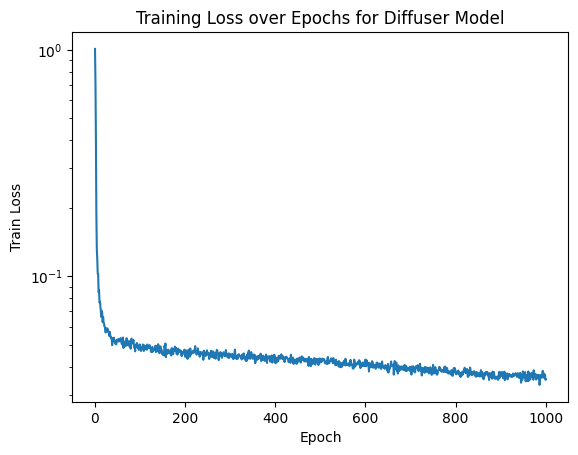

In [76]:
plt.plot(np.arange(1, len(train_losses) + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss over Epochs for Diffuser Model")
plt.yscale("log")
plt.show()

In [ ]:
torch.save(model.state_dict(), f"data/diffuser_unet_{time.strftime('%Y-%m-%d_%H-%M-%S')}.pth")

In [151]:
def sample_trajectory(model, noise_scheduler: Union[DDPMScheduler, DDIMScheduler], planning_horizon,
                      n_inference_steps, device=device, start_config=None, end_config=None, insertion_horizon=1):
    model.eval()

    if start_config is not None:
        start = torch.tensor(start_config, device=device) \
                if not isinstance(start_config, torch.Tensor) \
                else start_config.to(device)
        goal = torch.tensor(end_config, device=device) \
               if not isinstance(end_config, torch.Tensor) \
               else end_config.to(device)

    with torch.no_grad():
        x = torch.randn(1, planning_horizon, 7, device=device)
        noise_scheduler.set_timesteps(n_inference_steps)

        for i, t in enumerate(tqdm(noise_scheduler.timesteps)):
            t_batch = t.unsqueeze(0).to(device)
            noise_pred = model(x, t_batch)
            x = noise_scheduler.step(noise_pred, t, x).prev_sample

            if start_config is not None and end_config is not None:
                alpha_bar_t = noise_scheduler.alphas_cumprod[t].to(device)
                sqrt_alpha_bar_t = torch.sqrt(alpha_bar_t)
                sqrt_one_minus_alpha_bar_t = torch.sqrt(1 - alpha_bar_t)
                noise_start = torch.randn_like(start) if t > 0 else torch.zeros_like(start)
                noisy_start = sqrt_alpha_bar_t * start + sqrt_one_minus_alpha_bar_t * noise_start
                noise_goal = torch.randn_like(goal) if t > 0 else torch.zeros_like(goal)
                noisy_goal = sqrt_alpha_bar_t * goal + sqrt_one_minus_alpha_bar_t * noise_goal
                x[:, :insertion_horizon, :] = noisy_start
                x[:, -insertion_horizon:, :] = noisy_goal

        if start_config is not None and end_config is not None:
            x[:, :insertion_horizon, :] = start.squeeze(0)
            x[:, -insertion_horizon:, :] = goal.squeeze(0)

    return x.squeeze(0)  # [planning_horizon, 7]

In [173]:
trajectories_unnormalized = None
traj_idxs = [1, 2, 11, 55, 86]
for i in range(len(traj_idxs)):
    # Use DDIM for fast sampling
    model = UNet(joint_dim=joint_dim, down_channels=[256, 512, 1024], t_emb_dim=256, n_groups=8, kernel_size=5).to(device)
    # load_path = "/home/jwade19/Desktop/ME595R_DL/ME595R_DeepLearning/final_project/diffuser/data/diffuser_unet_100d_2026-04-01_19-12-11.pth"
    load_path = "/home/jwade19/Desktop/ME595R_DL/ME595R_DeepLearning/final_project/diffuser/data/diffuser_unet_4500_epochs_2026-03-31_21-29-50.pth"
    model.load_state_dict(torch.load(load_path, map_location=device))
    noise_scheduler = DDIMScheduler(num_train_timesteps=20, beta_start=1e-4, beta_end=0.02, beta_schedule="squaredcos_cap_v2", clip_sample=True, prediction_type="epsilon")
    torch.manual_seed(0)
    insertion_horizon = 5
    traj_idx = traj_idxs[i]
    traj_idx = i + 3

    start_config = dataset[traj_idx][:insertion_horizon]
    end_config = dataset[traj_idx][-insertion_horizon:]

    # start_config = None
    # end_config = None

    n_inference_steps = 20
    trajectory_normalized = sample_trajectory(model, noise_scheduler, planning_horizon=planning_horizon, n_inference_steps=n_inference_steps, device=device, start_config=start_config, end_config=end_config, insertion_horizon=insertion_horizon)
    trajectory_unnormalized = unnormalize_trajectories(trajectory_normalized.cpu().numpy(), stats)
    if trajectories_unnormalized is None:
        trajectories_unnormalized = trajectory_unnormalized
    else:
        trajectories_unnormalized = np.concatenate([trajectories_unnormalized, trajectory_unnormalized], axis=0)

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

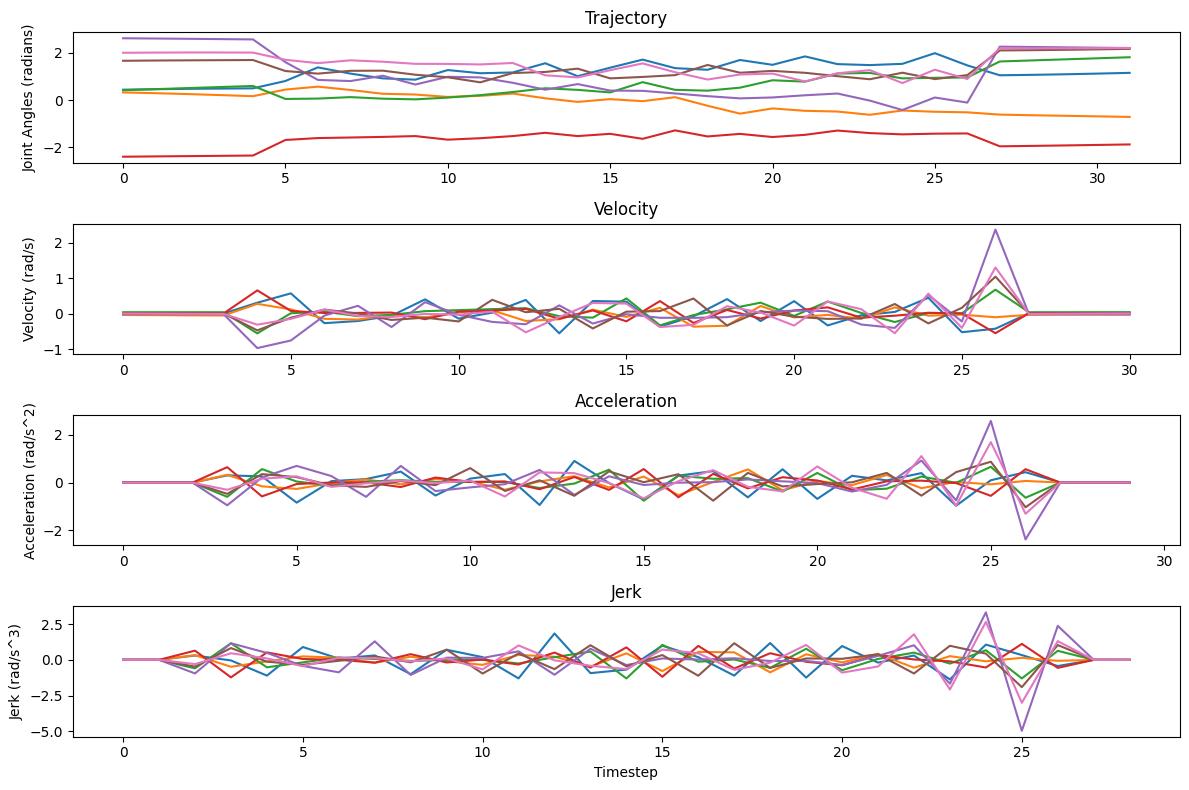

In [174]:
trajectory = trajectories_unnormalized[:planning_horizon]
v = np.diff(trajectory, axis=0)
acc = np.diff(v, axis=0)
jerk = np.diff(acc, axis=0)

plt.figure(figsize=(12, 8))
plt.subplot(4, 1, 1)
plt.plot(trajectory)
plt.title("Trajectory")
plt.ylabel("Joint Angles (radians)")
plt.subplot(4, 1, 2)
plt.plot(v)
plt.title("Velocity")
plt.ylabel("Velocity (rad/s)")
plt.subplot(4, 1, 3)
plt.plot(acc)
plt.title("Acceleration")
plt.ylabel("Acceleration (rad/s^2)")
plt.subplot(4, 1, 4)
plt.plot(jerk)
plt.title("Jerk")
plt.xlabel("Timestep")
plt.ylabel("Jerk (rad/s^3)")
plt.tight_layout()
plt.show()

In [93]:
view_trajectory_live(trajectories_unnormalized, panda_model, panda_data)
# if start_config is None and end_config is None:
#     save_path = f"media/unguided_trajectory_{time.strftime('%Y-%m-%d_%H-%M-%S')}.mp4"
# else:
#     save_path = f"media/guided_trajectory_{time.strftime('%Y-%m-%d_%H-%M-%S')}.mp4"
# render_trajectory_video(trajectories_unnormalized, panda_model, panda_data, save_path)

KeyboardInterrupt: 

In [ ]:
view_trajectory_live(unnormalize_trajectories(dataset[3], stats), panda_model, panda_data)

In [273]:
def collision_cost(trajectory: torch.Tensor, obstacles: list[tuple[torch.Tensor, float]], robot_chain: pk.Chain):
    """
    trajectory: [32, 7] real joint angles (requires_grad via x_in)
    obstacles: list of (center [3], radius)
    chain: pk serial chain
    """
    device = trajectory.device
    tfs = robot_chain.forward_kinematics(trajectory, end_only=False)  # [32, 7] -> Transform3d with batch dim 32
    cost = torch.tensor(0.0, device=device)
    margin = 0.1
    k = 10

    distances = []
    prev_pos = None
    for link_name, tf in tfs.items():
        link_pos = tf.get_matrix()[:, :3, 3]
        if prev_pos is not None:
            num_points = 5
            for alpha in torch.linspace(0, 1, num_points, device=device):
                interp_pos = prev_pos * (1 - alpha) + link_pos * alpha
        else:
            interp_pos = link_pos
        for center, radius in obstacles:
            dist = torch.norm(interp_pos - center.to(device), dim=-1)
            cost += torch.sum(k * (torch.relu(radius - dist + margin)**2))
            # cost += torch.sum(F.softplus(k * (radius - dist + margin))**2)
            distances.append(dist.detach().cpu().numpy())
        prev_pos = link_pos
    cost /= (len(tfs) * len(obstacles) * num_points)
    # print("Collision cost:", cost.item())
    return cost, distances

def sample_guided_trajectory(model, noise_scheduler: Union[DDPMScheduler, DDIMScheduler], planning_horizon, n_inference_steps, stats,
                             obstacles, robot, lambda_guidance = 0.5, device=torch.device('cuda'),
                             start_config=None, end_config=None, insertion_horizon=1, grad_clip=1.0, guidance_on_clean=True):
    model.eval()

    if start_config is not None:
        start = torch.tensor(start_config, device=device) \
                if not isinstance(start_config, torch.Tensor) \
                else start_config.to(device)
        goal = torch.tensor(end_config, device=device) \
               if not isinstance(end_config, torch.Tensor) \
               else end_config.to(device)
    x = torch.randn(1, planning_horizon, 7, device=device)
    noise_scheduler.set_timesteps(n_inference_steps)

    for t in tqdm(noise_scheduler.timesteps):
        x_in = x.detach().requires_grad_(True)
        t_batch = t.unsqueeze(0).to(device)

        with torch.no_grad():
            noise_pred = model(x_in, t_batch)

        # Take the DDIM step
        x_denoised = noise_scheduler.step(noise_pred, t, x_in).prev_sample  # [1, 32, 7]

        guidance_input = x_denoised if guidance_on_clean else x_in
        traj_real = unnormalize_trajectories_torch(x_denoised.squeeze(0), stats).float().requires_grad_(True)  # [planning_horizon, 7]
        cost, distances = collision_cost(traj_real, obstacles, robot)
        grad = torch.clamp(torch.autograd.grad(cost, guidance_input)[0], min=-grad_clip, max=grad_clip)
        # print("grad:" , grad.norm().item())

        # Apply
        x_denoised = x_denoised - lambda_guidance * grad.detach()

        if start_config is not None and end_config is not None:
            alpha_bar_t = noise_scheduler.alphas_cumprod[t].to(device)
            sqrt_alpha_bar_t = torch.sqrt(alpha_bar_t)
            sqrt_one_minus_alpha_bar_t = torch.sqrt(1 - alpha_bar_t)
            noise_start = torch.randn_like(start) if t > 0 else torch.zeros_like(start)
            noisy_start = sqrt_alpha_bar_t * start + sqrt_one_minus_alpha_bar_t * noise_start
            noise_goal = torch.randn_like(goal) if t > 0 else torch.zeros_like(goal)
            noisy_goal = sqrt_alpha_bar_t * goal + sqrt_one_minus_alpha_bar_t * noise_goal
            x_denoised[:, :insertion_horizon, :] = noisy_start
            x_denoised[:, -insertion_horizon:, :] = noisy_goal

        x = x_denoised

    if start_config is not None and end_config is not None:
        x[:, :insertion_horizon, :] = start.squeeze(0)
        x[:, -insertion_horizon:, :] = goal.squeeze(0)

    return x.squeeze(0), distances  # [planning_horizon, 7]

In [302]:
trajectories_unnormalized = None
traj_idxs = [1, 2, 11, 55, 86]
traj_idxs = [11]
for i in range(len(traj_idxs)):
    # Use DDIM for fast sampling
    model = UNet(joint_dim=joint_dim, down_channels=[256, 512, 1024], t_emb_dim=256, n_groups=8, kernel_size=5).to(device)
    # load_path = "/home/jwade19/Desktop/ME595R_DL/ME595R_DeepLearning/final_project/diffuser/data/diffuser_unet_100d_2026-04-01_19-12-11.pth"
    load_path = "/home/jwade19/Desktop/ME595R_DL/ME595R_DeepLearning/final_project/diffuser/data/diffuser_unet_4500_epochs_2026-03-31_21-29-50.pth"
    model.load_state_dict(torch.load(load_path, map_location=device))
    torch.manual_seed(0)
    noise_scheduler = DDIMScheduler(num_train_timesteps=20, beta_start=1e-4, beta_end=0.02, beta_schedule="squaredcos_cap_v2", clip_sample=True, prediction_type="epsilon")
    insertion_horizon = 5
    traj_idx = traj_idxs[i]

    start_config = dataset[traj_idx][:insertion_horizon]
    end_config = dataset[traj_idx][-insertion_horizon:]

    n_inference_steps = 20
    trajectory_normalized, distances = sample_guided_trajectory(model, noise_scheduler, planning_horizon=planning_horizon,
                                                    n_inference_steps=n_inference_steps, device=device, start_config=start_config,
                                                    end_config=end_config, stats=stats, obstacles=obstacles, lambda_guidance=30.0, guidance_on_clean=True,
                                                    robot=robot, insertion_horizon=insertion_horizon, grad_clip=1.0)
    trajectory_unnormalized = unnormalize_trajectories(trajectory_normalized.detach().cpu().numpy(), stats)
    if trajectories_unnormalized is None:
        trajectories_unnormalized = trajectory_unnormalized
    else:
        trajectories_unnormalized = np.concatenate([trajectories_unnormalized, trajectory_unnormalized], axis=0)

  0%|          | 0/20 [00:00<?, ?it/s]

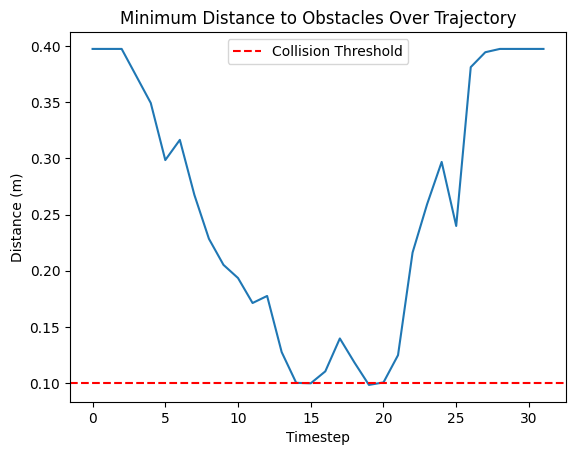

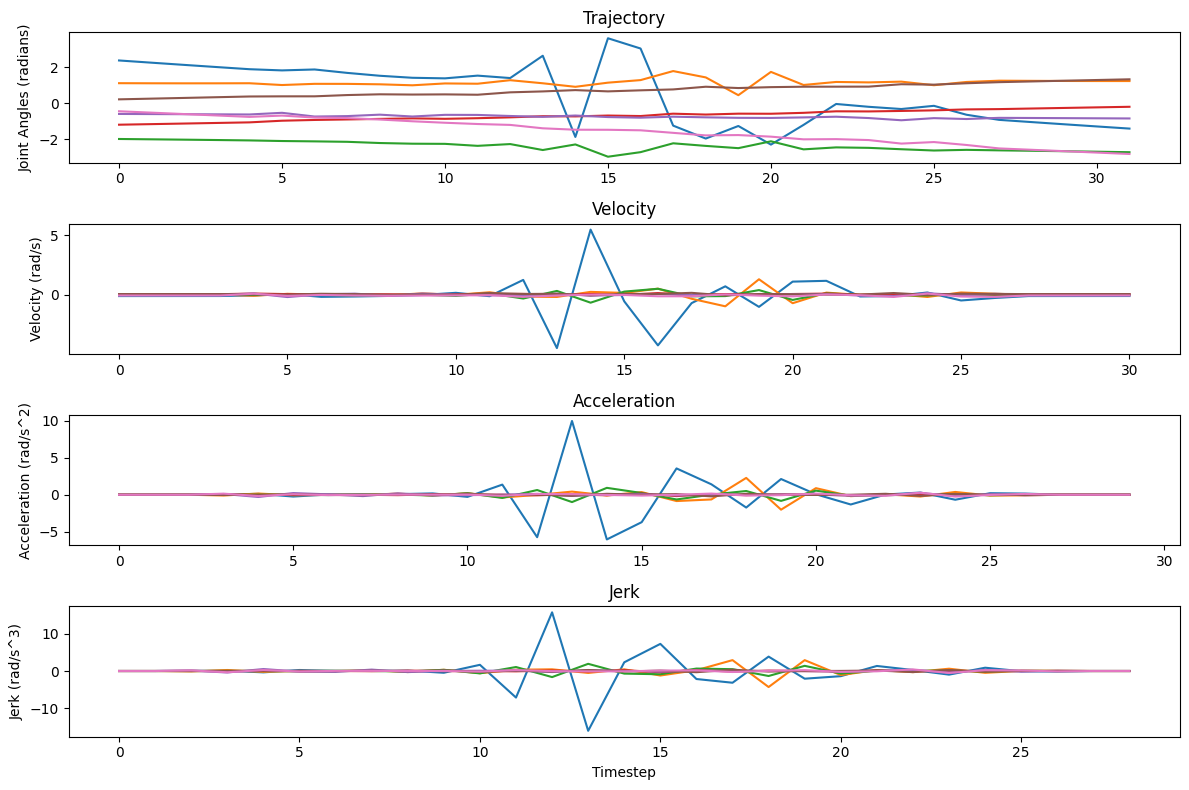

In [303]:
distances = np.array(distances)
min_distances = distances.min(axis=0)
plt.plot(min_distances)
plt.axhline(0.1, color='r', linestyle='--', label='Collision Threshold')
plt.title("Minimum Distance to Obstacles Over Trajectory")
plt.xlabel("Timestep")
plt.ylabel("Distance (m)")
plt.legend()
plt.show()

trajectory = trajectories_unnormalized[:planning_horizon]
v = np.diff(trajectory, axis=0)
acc = np.diff(v, axis=0)
jerk = np.diff(acc, axis=0)

plt.figure(figsize=(12, 8))
plt.subplot(4, 1, 1)
plt.plot(trajectory)
plt.title("Trajectory")
plt.ylabel("Joint Angles (radians)")
plt.subplot(4, 1, 2)
plt.plot(v)
plt.title("Velocity")
plt.ylabel("Velocity (rad/s)")
plt.subplot(4, 1, 3)
plt.plot(acc)
plt.title("Acceleration")
plt.ylabel("Acceleration (rad/s^2)")
plt.subplot(4, 1, 4)
plt.plot(jerk)
plt.title("Jerk")
plt.xlabel("Timestep")
plt.ylabel("Jerk (rad/s^3)")
plt.tight_layout()
plt.show()

In [305]:
# view_trajectory_live(trajectories_unnormalized, panda_model, panda_data)
save_path = f"media/guided_trajectory_{len(obstacles)}_obstacles_{time.strftime('%Y-%m-%d_%H-%M-%S')}.mp4"
render_trajectory_video(trajectories_unnormalized, panda_model, panda_data, save_path)

Saved video to media/guided_trajectory_1_obstacles_2026-04-01_20-36-00.mp4
